In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler,PowerTransformer
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score,confusion_matrix,ConfusionMatrixDisplay,classification_report
from sklearn.ensemble import RandomForestClassifier

In [2]:
df=pd.read_csv("heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:
df.dtypes

age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

In [4]:
df.shape

(299, 13)

In [5]:
df.isnull().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [6]:
df["DEATH_EVENT"].value_counts(normalize=True)

DEATH_EVENT
0    0.67893
1    0.32107
Name: proportion, dtype: float64

In [7]:
num=df.select_dtypes(include=np.number).columns.tolist()
num.remove("DEATH_EVENT")

In [8]:
print(num)

['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time']


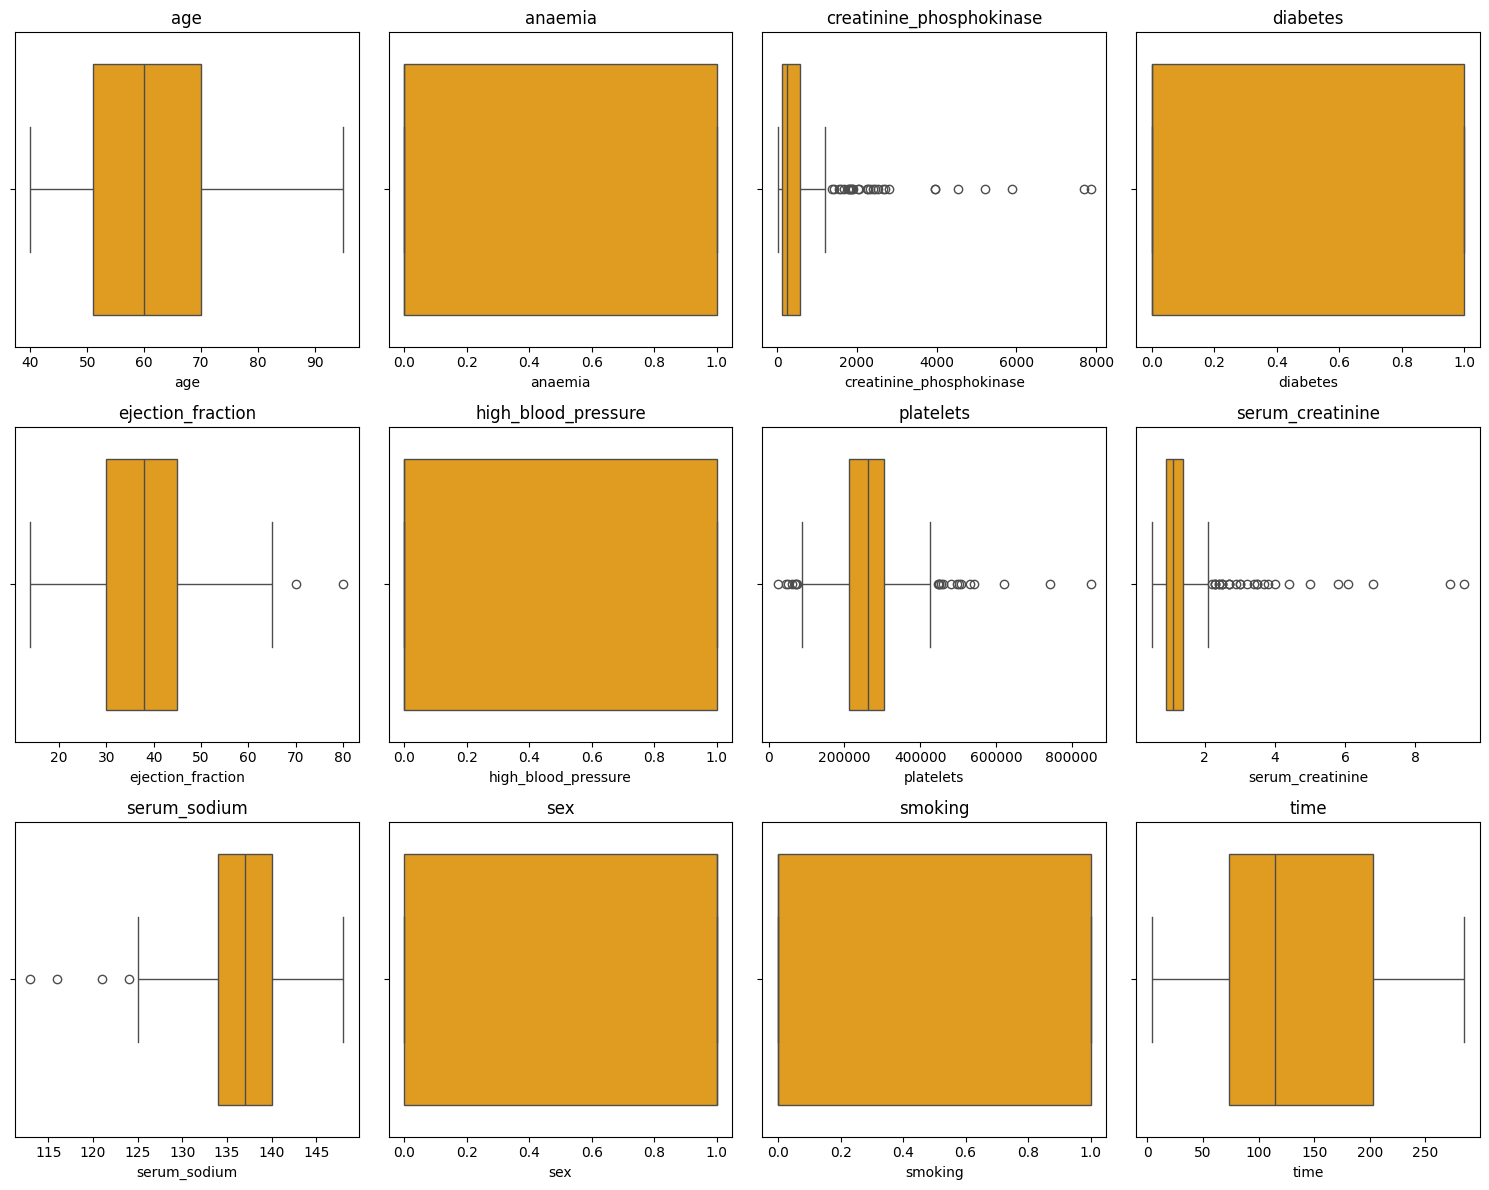

In [9]:
fig, ax = plt.subplots(3,4, figsize=(15,12))
ax = ax.flatten()

for i, col in enumerate(num):
    sns.boxplot(x=df[col], ax=ax[i], color='orange')
    ax[i].set_title(col)

plt.tight_layout()
plt.show()

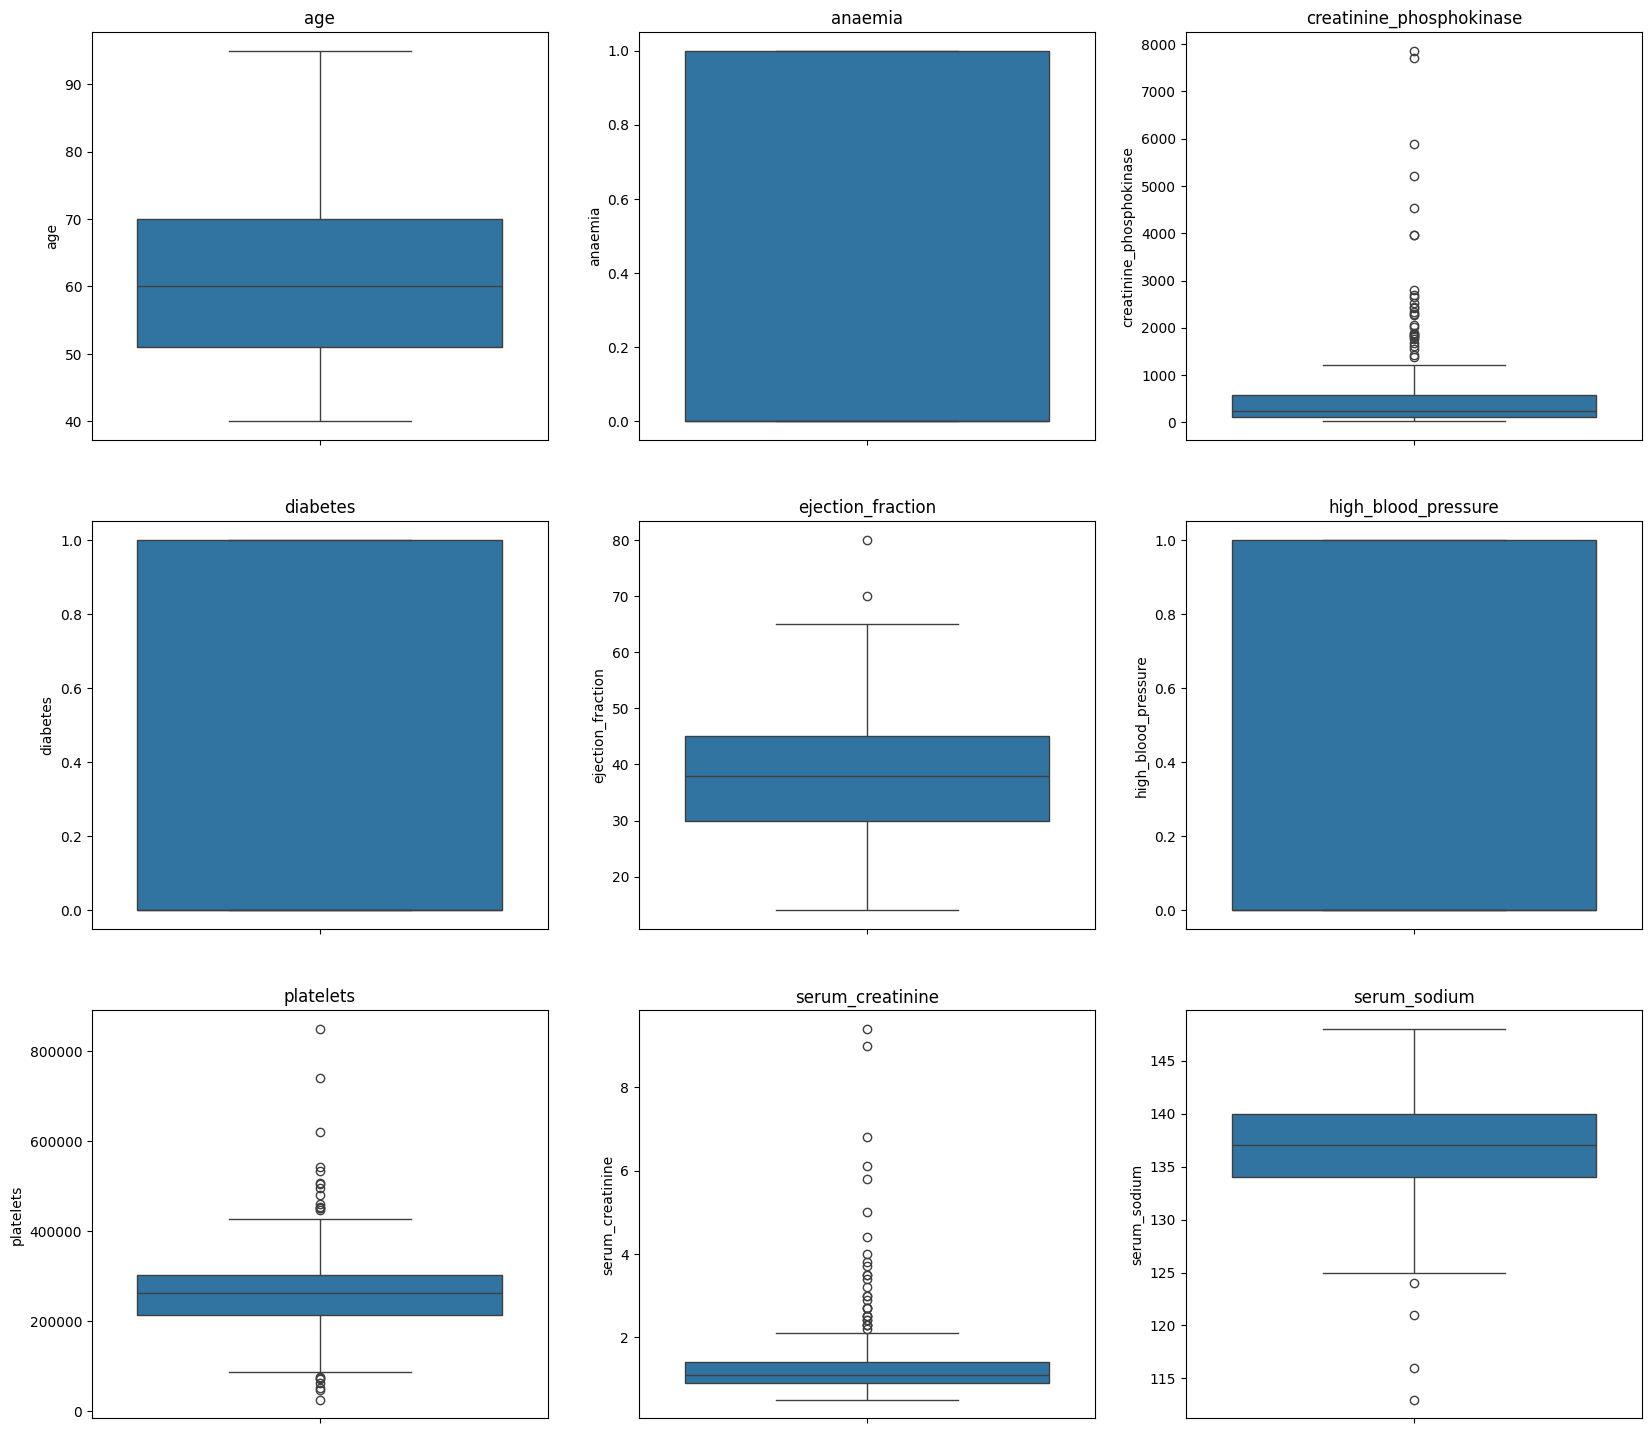

In [31]:
fig=plt.figure(figsize=(20,18))
n=range(1,10)
for x,n in zip(num,n):
        ax=fig.add_subplot(3,3,n)
        sns.boxplot(df[x],ax=ax)
        ax.set_title(x)
        
    



In [10]:
outliear_list=[]
for x in num:
    Q1=df[x].quantile(0.25)
    Q2=df[x].quantile(0.75)
    IQR=Q2-Q1
    lower=Q1-1.5*IQR
    high=Q2+1.5*IQR
    outliear=((df[x]<lower) | (df[x]>high)).sum()
    print(f"total outliear in {x} is {outliear}")
    if outliear >0:
        outliear_list.append(x)
print(outliear_list)


total outliear in age is 0
total outliear in anaemia is 0
total outliear in creatinine_phosphokinase is 29
total outliear in diabetes is 0
total outliear in ejection_fraction is 2
total outliear in high_blood_pressure is 0
total outliear in platelets is 21
total outliear in serum_creatinine is 29
total outliear in serum_sodium is 4
total outliear in sex is 0
total outliear in smoking is 0
total outliear in time is 0
['creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium']


In [11]:
for x in outliear_list:
    df[x]=np.log1p(df[x])

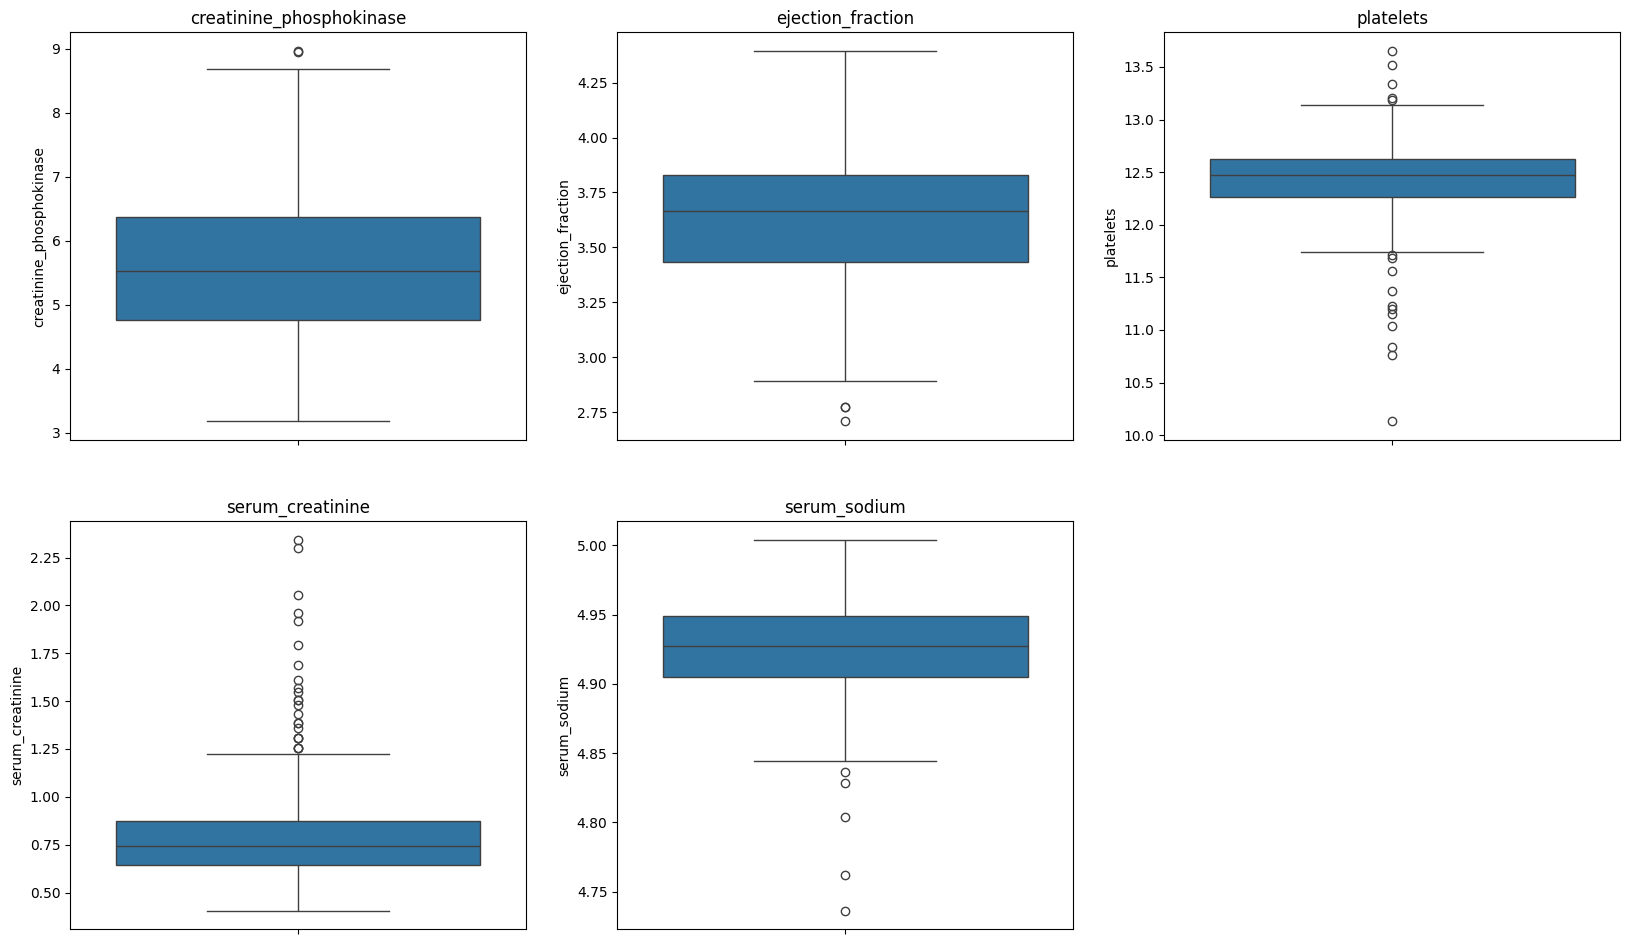

In [38]:
fig=plt.figure(figsize=(20,18))
n=range(1,10)
for x,n in zip(outliear_list,n):
        ax=fig.add_subplot(3,3,n)
        sns.boxplot(df[x],ax=ax)
        ax.set_title(x)

In [12]:
rb=RobustScaler()
x_data=rb.fit_transform(df[outliear_list])
df1=pd.DataFrame(x_data,columns=rb.get_feature_names_out(outliear_list),index=df.index)
df=pd.concat([df.drop(columns=outliear_list),df1],axis=1)

In [13]:
with open ("scale.pkl","wb")as f1:
    pickle.dump(rb,f1)

In [43]:
df.head()

,age,anaemia,diabetes,high_blood_pressure,sex,smoking,time,DEATH_EVENT,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium
0,75.0,0,0,1,1,0,4,1,0.526107,-1.568561,0.031942,1.381648,-1.197108
1,55.0,0,0,0,1,0,6,1,2.150255,0.000000,0.014504,0.000000,-0.167247
2,65.0,0,0,0,1,1,7,1,-0.334006,-1.568561,-1.348744,0.389409,-1.373326
3,50.0,1,0,0,1,0,7,1,-0.503770,-1.568561,-0.620683,1.381648,0.000000
4,65.0,1,1,0,0,0,8,1,-0.277213,-1.568561,0.621746,2.424484,-3.796236


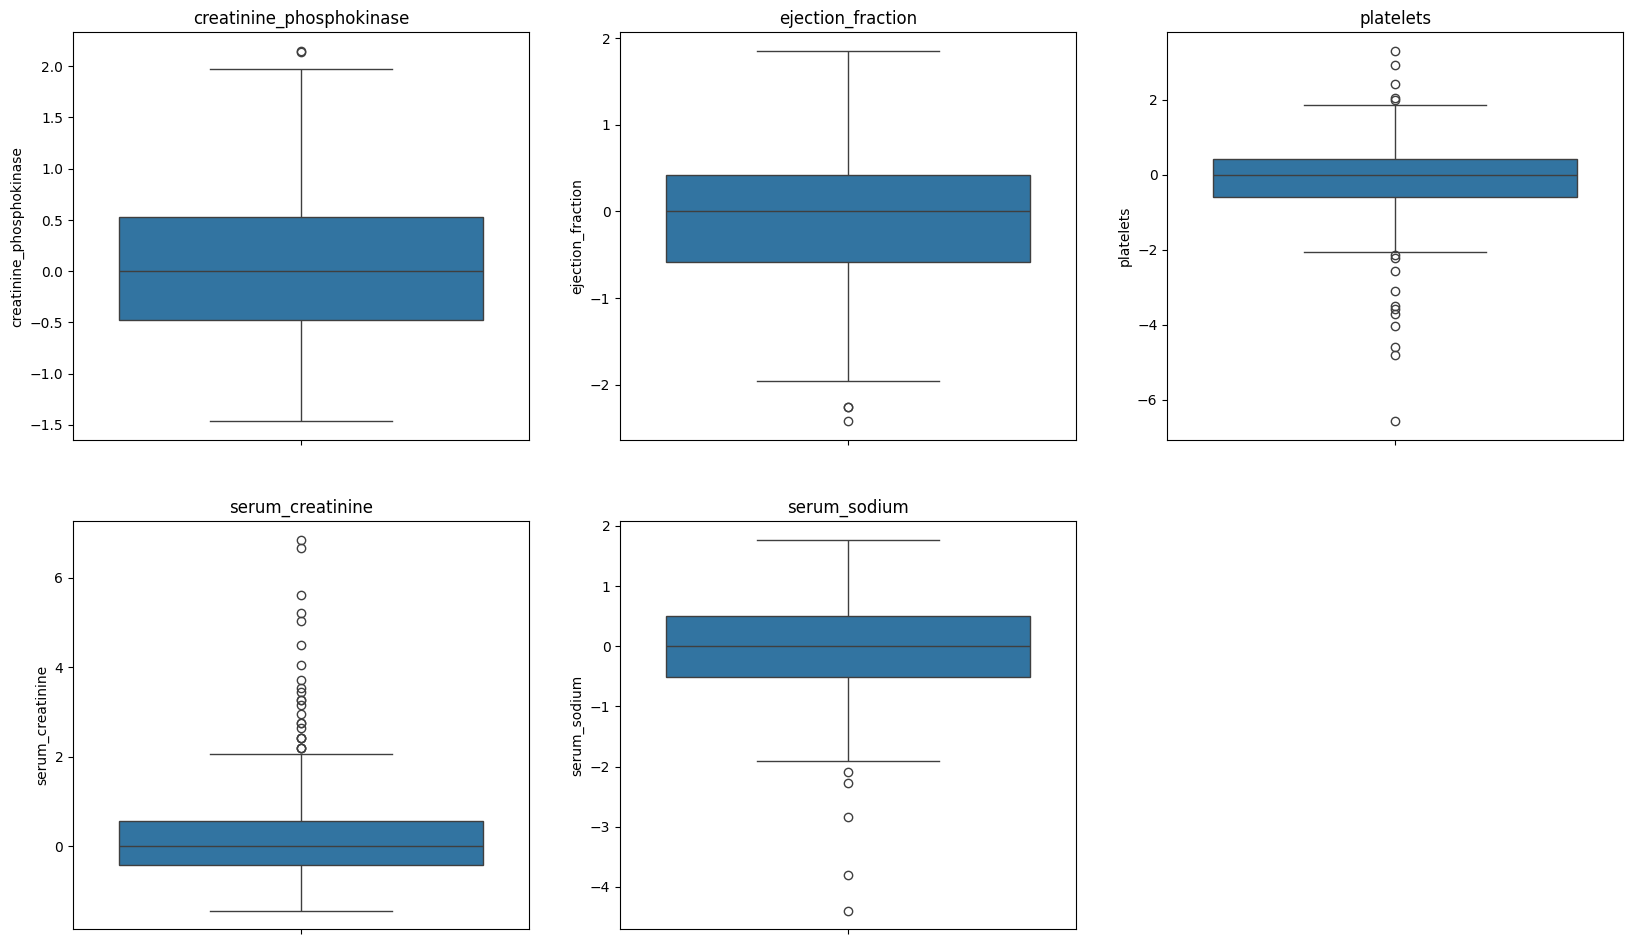

In [44]:
fig=plt.figure(figsize=(20,18))
n=range(1,10)
for x,n in zip(outliear_list,n):
        ax=fig.add_subplot(3,3,n)
        sns.boxplot(df[x],ax=ax)
        ax.set_title(x)

In [48]:
df[outliear_list].skew()

creatinine_phosphokinase    0.422715
ejection_fraction          -0.245770
platelets                  -1.284928
serum_creatinine            2.313207
serum_sodium               -1.310145
dtype: float64

In [50]:
X=df.drop("DEATH_EVENT",axis=1)

In [52]:
y=df["DEATH_EVENT"]

In [53]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [58]:
lr=LogisticRegression(class_weight="balanced",random_state=42,max_iter=200,n_jobs=-1)
lr.fit(X_train,y_train)
print("f1 score is ",f1_score(y_test,lr.predict(X_test)))
print("accuracy_score is",accuracy_score(y_test,lr.predict(X_test)))

f1 score is  0.6956521739130435
accuracy_score is 0.7666666666666667


<Axes: >

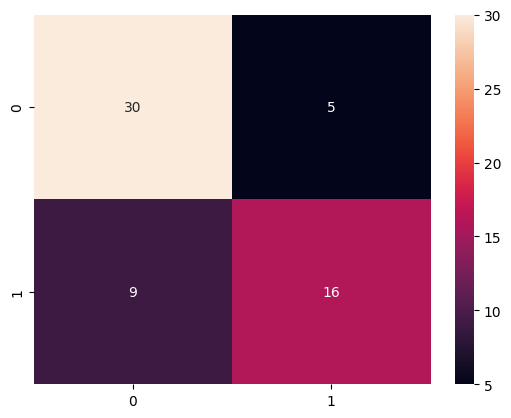

In [60]:
con_mat=confusion_matrix(y_test,lr.predict(X_test))
sns.heatmap(con_mat,annot=True)

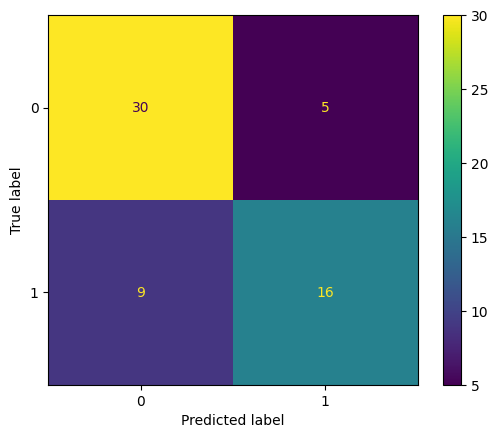

In [61]:
cd=ConfusionMatrixDisplay(confusion_matrix=con_mat)
cd.plot()

In [64]:
print("classification report is\n",classification_report(y_test,lr.predict(X_test)))

classification report is
               precision    recall  f1-score   support

           0       0.77      0.86      0.81        35
           1       0.76      0.64      0.70        25

    accuracy                           0.77        60
   macro avg       0.77      0.75      0.75        60
weighted avg       0.77      0.77      0.76        60



In [66]:
lr1=LogisticRegression(n_jobs=-1)

In [75]:
best_param={"penalty":["l1","l2"],
            "max_iter":np.arange(100,1000,100),
            "solver":["liblinear","lbfgs","sag","saga"],
            "C":np.arange(1,10,1),
           "class_weight":(None,"balanced") }

In [76]:
cv=StratifiedKFold(n_splits=5,shuffle=True)

In [77]:
scoring = {
    'accuracy': 'accuracy',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

In [78]:
grid=GridSearchCV(lr1,param_grid=best_param,cv=cv,scoring=scoring,refit="roc_auc",verbose=2,n_jobs=-1)
grid.fit(X_train,y_train)

Fitting 5 folds for each of 1296 candidates, totalling 6480 fits


c:\Users\kunda\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
1620 fits failed out of a total of 6480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
810 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\kunda\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\kunda\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 1363, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\kunda\AppData\Local\Programs\Python\Python310\lib\site-pa

,estimator,LogisticRegression(n_jobs=-1)
,param_grid,"{'C': array([1, 2, ..., 6, 7, 8, 9]), 'class_weight': (None, ...), 'max_iter': array([100, 2...00, 800, 900]), 'penalty': ['l1', 'l2'], ...}"
,scoring,"{'accuracy': 'accuracy', 'f1': 'f1', 'recall': 'recall', 'roc_auc': 'roc_auc'}"
,n_jobs,-1
,refit,'roc_auc'
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [79]:
score_df=pd.DataFrame(grid.cv_results_)
score_df

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_class_weight,param_max_iter,param_penalty,param_solver,params,...,std_test_f1,rank_test_f1,split0_test_roc_auc,split1_test_roc_auc,split2_test_roc_auc,split3_test_roc_auc,split4_test_roc_auc,mean_test_roc_auc,std_test_roc_auc,rank_test_roc_auc
0,0.034359,0.028883,0.047163,0.018312,1,None,100,l1,liblinear,"{'C': 1, 'class_weight': None, 'max_iter': 100...",...,0.111327,910,0.911111,0.787815,0.829832,0.930672,0.956710,0.883228,0.063848,334
1,0.001396,0.000489,0.000000,0.000000,1,None,100,l1,lbfgs,"{'C': 1, 'class_weight': None, 'max_iter': 100...",...,NaN,973,NaN,NaN,NaN,NaN,NaN,NaN,NaN,973
2,0.001795,0.001163,0.000000,0.000000,1,None,100,l1,sag,"{'C': 1, 'class_weight': None, 'max_iter': 100...",...,NaN,973,NaN,NaN,NaN,NaN,NaN,NaN,NaN,973
3,0.085192,0.022964,0.023378,0.009268,1,None,100,l1,saga,"{'C': 1, 'class_weight': None, 'max_iter': 100...",...,0.084240,160,0.870707,0.735294,0.825630,0.928571,0.969697,0.865980,0.081736,972
4,0.007827,0.002093,0.026826,0.002945,1,None,100,l2,liblinear,"{'C': 1, 'class_weight': None, 'max_iter': 100...",...,0.109806,946,0.917172,0.785714,0.825630,0.924370,0.956710,0.881919,0.064903,360
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1291,0.133402,0.003201,0.019607,0.002852,9,balanced,900,l1,saga,"{'C': 9, 'class_weight': 'balanced', 'max_iter...",...,0.100777,243,0.896970,0.792017,0.867647,0.955882,0.967532,0.896010,0.063750,86
1292,0.007922,0.000881,0.021663,0.002688,9,balanced,900,l2,liblinear,"{'C': 9, 'class_weight': 'balanced', 'max_iter...",...,0.097225,568,0.894949,0.781513,0.810924,0.913866,0.954545,0.871159,0.064819,939
1293,0.109299,0.024478,0.021589,0.003630,9,balanced,900,l2,lbfgs,"{'C': 9, 'class_weight': 'balanced', 'max_iter...",...,0.093256,723,0.890909,0.783613,0.815126,0.913866,0.958874,0.872478,0.064348,867
1294,0.093683,0.007110,0.023417,0.003456,9,balanced,900,l2,sag,"{'C': 9, 'class_weight': 'balanced', 'max_iter...",...,0.108893,470,0.907071,0.804622,0.859244,0.955882,0.961039,0.897572,0.059375,28


In [87]:
best_recall=score_df.loc[score_df["mean_test_recall"].idxmax()]
print(best_recall)
best_recall_params = best_recall['params']
print(best_recall_params)

mean_fit_time                                                    0.063292
std_fit_time                                                     0.032054
mean_score_time                                                  0.039704
std_score_time                                                    0.01316
param_C                                                                 1
param_class_weight                                               balanced
param_max_iter                                                        300
param_penalty                                                          l2
param_solver                                                          sag
params                  {'C': 1, 'class_weight': 'balanced', 'max_iter...
split0_test_accuracy                                             0.791667
split1_test_accuracy                                               0.8125
split2_test_accuracy                                             0.708333
split3_test_accuracy                  

In [81]:
lr_new=grid.best_estimator_

c:\Users\kunda\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


f1 socre is 0.7083333333333334


<Axes: >

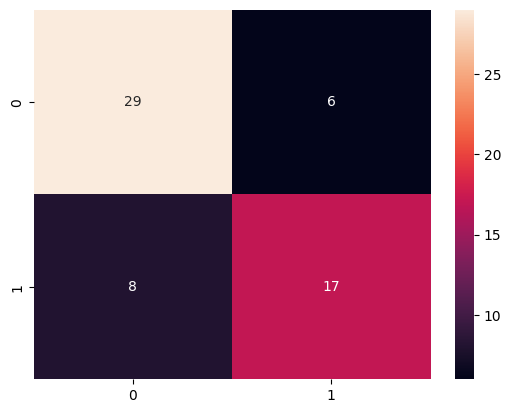

In [90]:
lr_new.fit(X_train,y_train)
y_pr=lr_new.predict(X_test)
print("f1 socre is",f1_score(y_test,y_pr))
sns.heatmap(confusion_matrix(y_test,y_pr),annot=True)

# Lets train on best params on best recall

In [91]:
best_recall=score_df.loc[score_df["mean_test_recall"].idxmax()]
print(best_recall)
best_recall_params = best_recall['params']
print(best_recall_params)

mean_fit_time                                                    0.063292
std_fit_time                                                     0.032054
mean_score_time                                                  0.039704
std_score_time                                                    0.01316
param_C                                                                 1
param_class_weight                                               balanced
param_max_iter                                                        300
param_penalty                                                          l2
param_solver                                                          sag
params                  {'C': 1, 'class_weight': 'balanced', 'max_iter...
split0_test_accuracy                                             0.791667
split1_test_accuracy                                               0.8125
split2_test_accuracy                                             0.708333
split3_test_accuracy                  

f1_score is 0.6923076923076923


c:\Users\kunda\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


<Axes: >

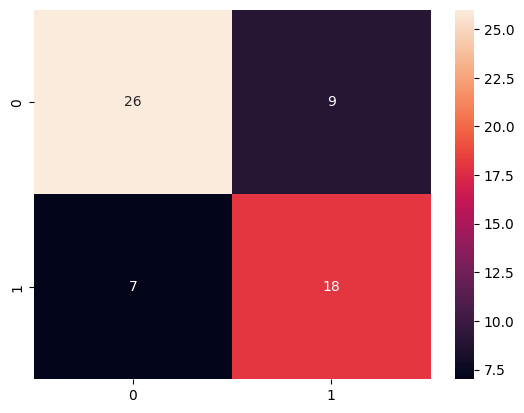

In [ ]:
lr_re=LogisticRegression(C=1,class_weight="balanced",max_iter=300,penalty="l2",solver="sag",random_state=42,n_jobs=-1)
lr_re.fit(X_train,y_train)
y_pr_re=lr_re.predict(X_test)
print("f1_score is",f1_score(y_test,y_pr_re))
sns.heatmap(confusion_matrix(y_test,y_pr_re),annot=True)

In [138]:
with open ("lr_re.pkl","wb") as f:
    pickle.dump(lr_re,f)

In [137]:
with open ("lr_new.pkl","wb") as f:
    pickle.dump(lr_new,f)

In [104]:
thre=np.arange(0.1,1,0.1)
f1=[]
y_pre_re_prob=lr_re.predict_proba(X_test)[:,1]
for x in thre:
    new_prd=(y_pre_re_prob>=x).astype(int)
    f1.append(f1_score(y_test,new_prd))
print("best thareshold is ",thre[np.argmax(f1)])
print("f1_score",max(f1))
print(f1)

best thareshold is  0.5
f1_score 0.6923076923076923
[0.6578947368421053, 0.6666666666666666, 0.6229508196721312, 0.6785714285714286, 0.6923076923076923, 0.6341463414634146, 0.631578947368421, 0.48484848484848486, 0.27586206896551724]


<Axes: >

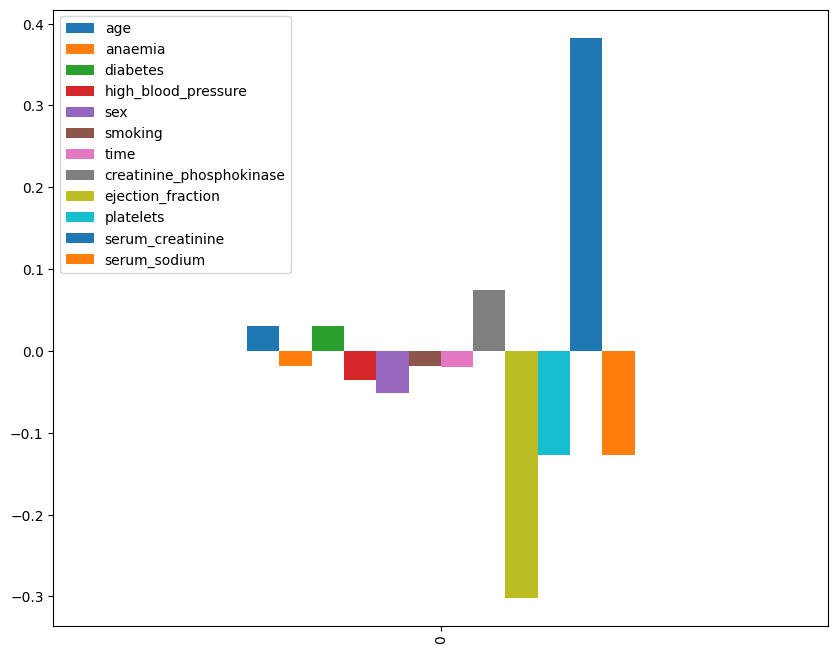

In [112]:
cof_df=pd.DataFrame((lr_re.coef_),columns=X.columns)
cof_df.plot(kind='bar',figsize=(10,8))

In [119]:

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_split=8,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train,y_train)
y_pre_rdc=rf.predict(X_test)
print(f1_score(y_train,rf.predict(X_train)))
print(f1_score(y_test,y_pre_rdc))

0.8979591836734694
0.6956521739130435


In [122]:
best_params={
    "n_estimators":np.arange(100,1000,100),
    "max_depth":np.arange(4,10,1),
    "min_samples_split":np.arange(4,15,1),
    "min_samples_split":np.arange(4,15,1),
    "class_weight":[None,"balanced"]
}

In [123]:
rf1=RandomForestClassifier(random_state=42,max_features="sqrt",n_jobs=-1)
grid2=GridSearchCV(rf1,param_grid=best_params,cv=cv,scoring="f1",verbose=2,n_jobs=-1)
grid2.fit(X_train,y_train)

Fitting 5 folds for each of 1188 candidates, totalling 5940 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'class_weight': [None, 'balanced'], 'max_depth': array([4, 5, 6, 7, 8, 9]), 'min_samples_split': array([ 4, 5..., 12, 13, 14]), 'n_estimators': array([100, 2...00, 800, 900])}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [128]:
grid2.best_params_

{'class_weight': 'balanced',
 'max_depth': 4,
 'min_samples_split': 8,
 'n_estimators': 100}

In [129]:
grid2.best_score_

0.8064814814814814

In [124]:
best_model=grid2.best_estimator_

In [130]:
best_model.fit(X_train,y_train)
best_prd=best_model.predict(X_test)
print("best f1 score is",f1_score(y_test,best_prd))
print("train f1 score",f1_score(y_train,best_model.predict(X_train)))


best f1 score is 0.7111111111111111
train f1 score 0.8888888888888888


In [127]:
import pickle
with open("best_model_rf.pkl","wb") as f1:
    pickle.dump(best_model,f1)

In [132]:
with open ("features.pkl","wb") as f2:
    pickle.dump(X.columns.to_list(),f2)

In [134]:
with open("best_model_rf.pkl","rb")as f3:

    model=pickle.load(f3)

In [135]:
print(f1_score(y_test,model.predict(X_test)))

0.7111111111111111
